In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ANALYSE & PREPROCESSING

In [2]:
data=pd.read_csv("credit_card_fraud_2025.csv")

In [3]:
data.shape

(500000, 16)

In [4]:
data.head()

,Transaction_ID,Customer_ID,Transaction_Date,Amount,Merchant_Category,Merchant_ID,Card_Type,Transaction_Type,Country,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Device_Type,Fraud_Flag
0,1,25795,2025-05-28 11:54:36,81.53,Online Services,8459,Gold,POS,Germany,1,1,0,1.61,11,Web,0
1,2,10860,2024-09-11 20:26:12,52.19,Fuel,8205,Debit,ATM,Germany,0,1,0,15.77,20,Web,0
2,3,86820,2024-11-02 12:39:23,27.70,Utilities,8076,Gold,Online,USA,0,1,0,9.19,12,Terminal,0
3,4,64886,2024-10-08 21:58:08,9.80,Clothing,3244,Gold,ATM,USA,0,1,0,9.42,21,Web,0
4,5,16265,2024-05-25 20:01:21,178.06,Electronics,3675,Gold,ATM,Germany,0,1,1,1.32,20,Web,0


In [5]:
data.dtypes

Transaction_ID          int64
Customer_ID             int64
Transaction_Date          str
Amount                float64
Merchant_Category         str
Merchant_ID             int64
Card_Type                 str
Transaction_Type          str
Country                   str
Is_International        int64
Is_Chip                 int64
Is_Pin_Used             int64
Distance_From_Home    float64
Hour_of_Day             int64
Device_Type               str
Fraud_Flag              int64
dtype: object

#### PB identifié:
- Transaction ID inutile & Customer ID
- Transaction Date est de type str
- Merchant_Category est str
- Card_Type est str
- Transaction_Type est str
- Country est str
- Device_Type est str

In [6]:
data.isna().sum()

Transaction_ID        0
Customer_ID           0
Transaction_Date      0
Amount                0
Merchant_Category     0
Merchant_ID           0
Card_Type             0
Transaction_Type      0
Country               0
Is_International      0
Is_Chip               0
Is_Pin_Used           0
Distance_From_Home    0
Hour_of_Day           0
Device_Type           0
Fraud_Flag            0
dtype: int64

In [7]:
### Suppresion de Transaction_ID:
data=data.drop(["Transaction_ID"], axis=1)

In [8]:
### Convertir le type date en date/float
data['Transaction_Date'] = pd.to_datetime(data['Transaction_Date'], format="%Y-%m-%d %H:%M:%S")

# Pour obtenir l'heure (format numérique)
#data['Hour'] = data['Transaction_Date'].dt.hour

# Pour obtenir le jour
#data['Day'] = data['Transaction_Date'].dt.day

# Si je veux vraiment "couper" la date pour en faire un float (Timestamp)
data['Timestamp'] = data['Transaction_Date'].astype('int64') // 10**9

In [9]:
data["Merchant_Category"].value_counts()

Merchant_Category
Electronics        50285
Fuel               50239
Health             50228
Groceries          50128
Online Services    50030
Food               50011
Clothing           49929
Utilities          49914
Entertainment      49808
Travel             49428
Name: count, dtype: int64

In [10]:
### Encoder Merchant_Category avec Multiencodage
new_merchant=data.groupby('Merchant_Category').size()/len(data)
data.loc[:,'Merchant_Category_encode']=data['Merchant_Category'].map(new_merchant)

In [11]:
data["Card_Type"].value_counts()

Card_Type
Platinum    125325
Debit       125020
Credit      124901
Gold        124754
Name: count, dtype: int64

In [12]:
### Encoder Card_Type avec Multiencodage
new_card=data.groupby('Card_Type').size()/len(data)
data.loc[:,'Card_Type_encode']=data['Card_Type'].map(new_card)

In [13]:
data["Transaction_Type"].value_counts()

Transaction_Type
Online    166827
POS       166618
ATM       166555
Name: count, dtype: int64

In [14]:
### Encoder Transaction_Type avec Multiencodage
new_transaction=data.groupby('Transaction_Type').size()/len(data)
data.loc[:,'Transaction_Type_encode']=data['Transaction_Type'].map(new_transaction)

In [15]:
data['Country'].value_counts()

Country
UK           62792
Canada       62714
France       62623
Australia    62552
Germany      62420
India        62350
Singapore    62283
USA          62266
Name: count, dtype: int64

In [16]:
new_country=data.groupby('Country').size()/len(data)
data.loc[:,'Country_encode']=data['Country'].map(new_country)

In [17]:
data["Device_Type"].value_counts()

Device_Type
Mobile      167230
Terminal    166732
Web         166038
Name: count, dtype: int64

In [18]:
new_device=data.groupby('Device_Type').size()/len(data)
data.loc[:,'Device_Type_encode']=data['Device_Type'].map(new_device)

In [19]:
data=data.drop(["Customer_ID","Device_Type","Country","Merchant_Category","Merchant_ID","Card_Type","Transaction_Type"], axis=1)

In [20]:
data.head()

,Transaction_Date,Amount,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Fraud_Flag,Timestamp,Merchant_Category_encode,Card_Type_encode,Transaction_Type_encode,Country_encode,Device_Type_encode
0,2025-05-28 11:54:36,81.53,1,1,0,1.61,11,0,1748433,0.100060,0.249508,0.333236,0.124840,0.332076
1,2024-09-11 20:26:12,52.19,0,1,0,15.77,20,0,1726086,0.100478,0.250040,0.333110,0.124840,0.332076
2,2024-11-02 12:39:23,27.70,0,1,0,9.19,12,0,1730551,0.099828,0.249508,0.333654,0.124532,0.333464
3,2024-10-08 21:58:08,9.80,0,1,0,9.42,21,0,1728424,0.099858,0.249508,0.333110,0.124532,0.332076
4,2024-05-25 20:01:21,178.06,0,1,1,1.32,20,0,1716667,0.100570,0.249508,0.333110,0.124840,0.332076


In [21]:
data.dtypes

Transaction_Date            datetime64[us]
Amount                             float64
Is_International                     int64
Is_Chip                              int64
Is_Pin_Used                          int64
Distance_From_Home                 float64
Hour_of_Day                          int64
Fraud_Flag                           int64
Timestamp                            int64
Merchant_Category_encode           float64
Card_Type_encode                   float64
Transaction_Type_encode            float64
Country_encode                     float64
Device_Type_encode                 float64
dtype: object

### Identification des valeurs abérantes

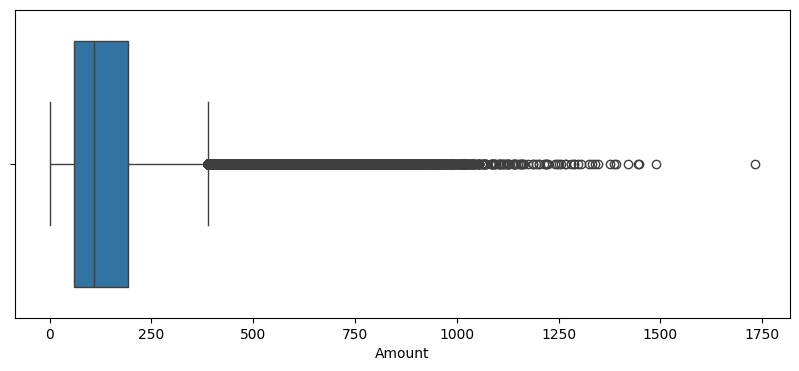

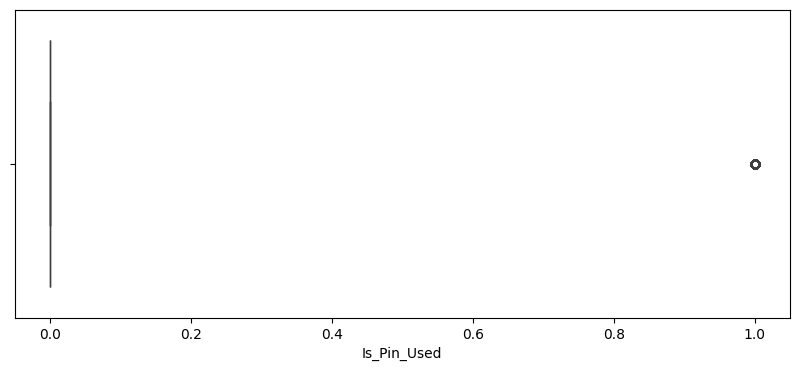

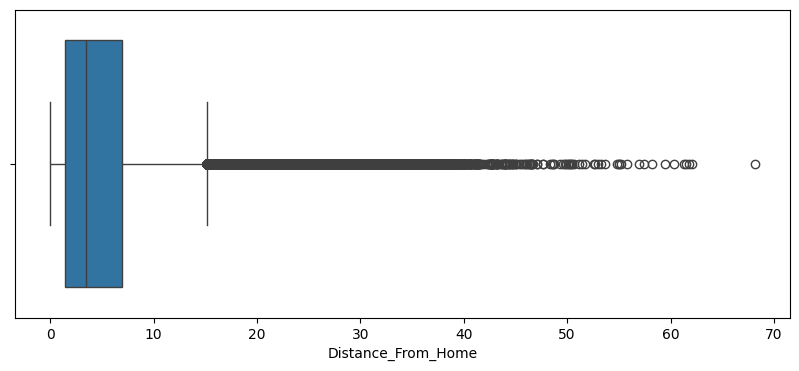

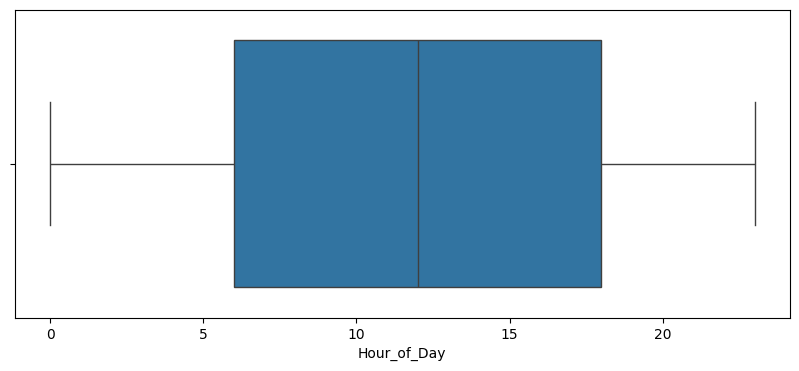

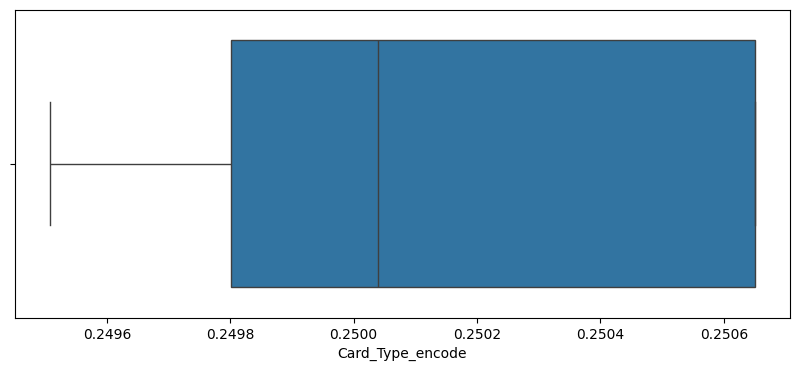

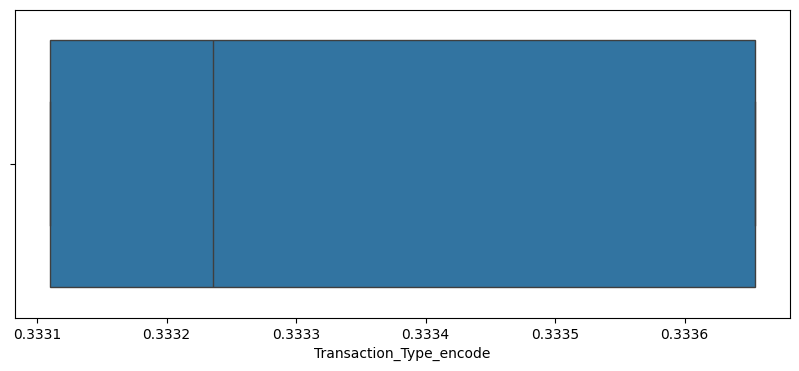

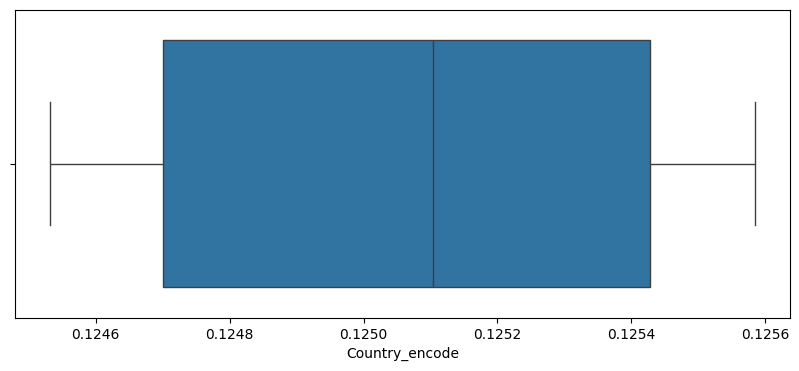

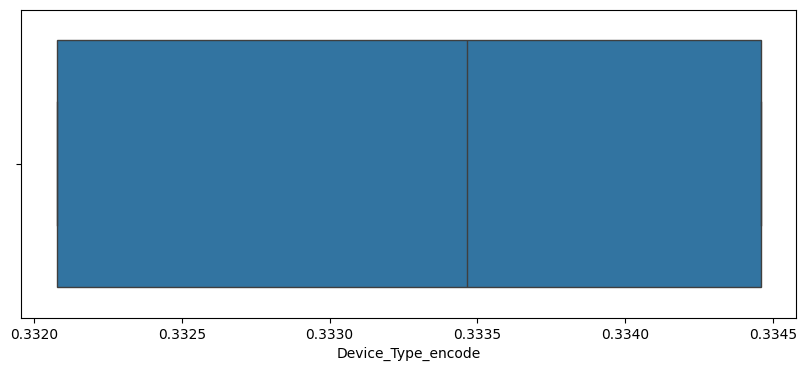

In [22]:
valeur=["Amount","Is_Pin_Used","Distance_From_Home","Hour_of_Day","Card_Type_encode","Transaction_Type_encode","Country_encode","Device_Type_encode"]
for x in valeur:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=data[x])

#### Variable avec les valeurs abérantes:
- Amount
- Distance_From_Home

### Traitement des valeurs abérantes

In [23]:
import numpy as np

def replace_outliers(df, target_column):
    # On sélectionne les colonnes numériques SAUF la target
    cols_to_process = df.select_dtypes(include=['number']).columns.drop(target_column)
    
    for col in cols_to_process:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR  
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    
    return df



In [24]:
# Utilisation
data = replace_outliers(data, 'Fraud_Flag')

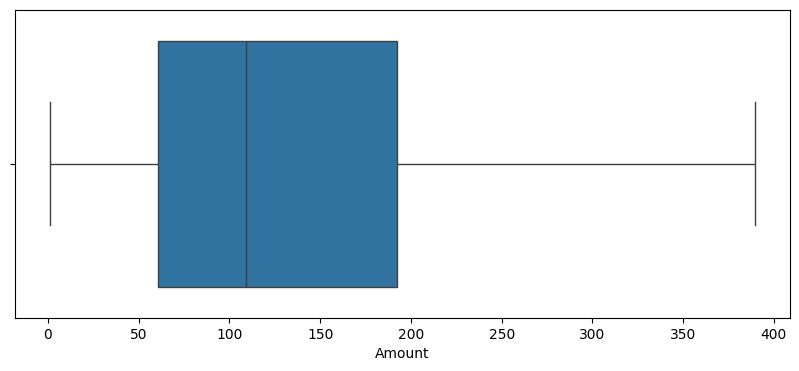

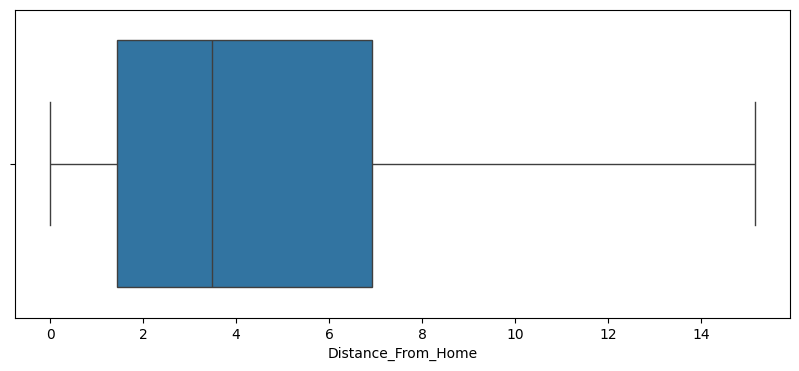

In [25]:
valeur=["Amount","Distance_From_Home"]
for x in valeur:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=data[x])

<Axes: >

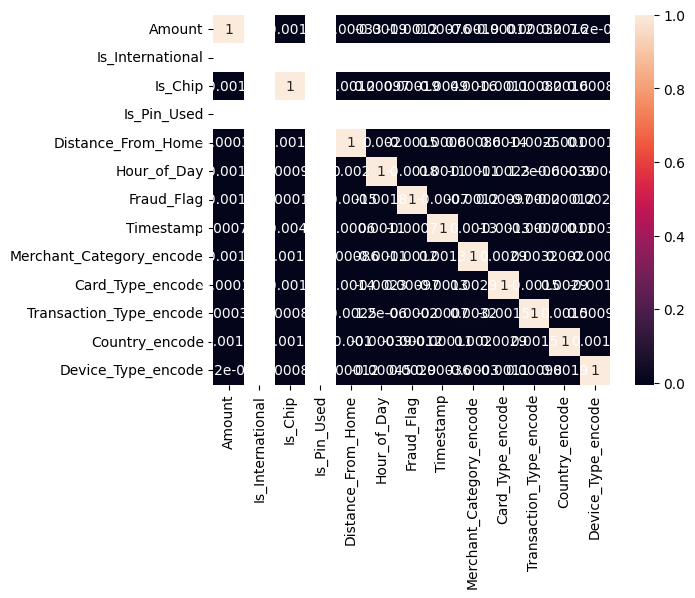

In [26]:
sns.heatmap(data.select_dtypes(include=['number']).corr(),annot=True)

### Aucune correlation réelle entre les variables

In [27]:
data.head()

,Transaction_Date,Amount,Is_International,Is_Chip,Is_Pin_Used,Distance_From_Home,Hour_of_Day,Fraud_Flag,Timestamp,Merchant_Category_encode,Card_Type_encode,Transaction_Type_encode,Country_encode,Device_Type_encode
0,2025-05-28 11:54:36,81.53,0.0,1.0,0.0,1.610,11.0,0,1748433.0,0.100060,0.249508,0.333236,0.124840,0.332076
1,2024-09-11 20:26:12,52.19,0.0,1.0,0.0,15.155,20.0,0,1726086.0,0.100478,0.250040,0.333110,0.124840,0.332076
2,2024-11-02 12:39:23,27.70,0.0,1.0,0.0,9.190,12.0,0,1730551.0,0.099828,0.249508,0.333654,0.124532,0.333464
3,2024-10-08 21:58:08,9.80,0.0,1.0,0.0,9.420,21.0,0,1728424.0,0.099858,0.249508,0.333110,0.124532,0.332076
4,2024-05-25 20:01:21,178.06,0.0,1.0,0.0,1.320,20.0,0,1716667.0,0.100570,0.249508,0.333110,0.124840,0.332076


In [28]:
data.dtypes
data.drop(["Transaction_Date"], axis=1, inplace=True)
data.dtypes

Amount                      float64
Is_International            float64
Is_Chip                     float64
Is_Pin_Used                 float64
Distance_From_Home          float64
Hour_of_Day                 float64
Fraud_Flag                    int64
Timestamp                   float64
Merchant_Category_encode    float64
Card_Type_encode            float64
Transaction_Type_encode     float64
Country_encode              float64
Device_Type_encode          float64
dtype: object

In [29]:

X=data.drop(["Fraud_Flag"], axis=1)
Y=data[["Fraud_Flag"]]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

"""linear=LogisticRegression()
linear.fit(X_train,y_train)
Y.value_counts()"""
### On équilibre car il y'a déséquilibre des classes 0 et 1

'linear=LogisticRegression()\nlinear.fit(X_train,y_train)\nY.value_counts()'

#### On a déséquilibre des classes, so, je génère les données de la classe 1, ou je diminue l'autre
- Undersampling(diminuer, mais c'est risqué, car perte de données)
- Oversampling(Générer des lignes artificielles). Ex: Pour générer, on utilise KNN(chercher dans ce sens). On a des techniques pour le faire, mais on a des librairies mais moins efficace

#### On part sur du Oversampling + Undersampling

In [30]:
### Comment gérer la date? En format numérique(float) ou en format date?
## Je crée un new_data_frame qui a drop y, puis je fais un concat avec ce qui était là(qui a été traité). On utilise pd.concat

https://link.springer.com/article/10.1186/s40537-025-01119-4 : Méthode pour Gérer le désequilibre des classes

SMOTE + ENN (Combinaison)

Principe :

SMOTE crée des fraudes synthétiques en interpolant entre 2 fraudes réelles proches
ENN (Edited Nearest Neighbors) nettoie ensuite en supprimant les échantillons (fraudes ou normales) mal classés par leurs voisins

Pourquoi pour nous :

- Évite de créer du bruit (ENN nettoie)
- Donne des fraudes réalistes sans duplication
- Idéal pour régression logistique car évite l'overfitting

In [31]:
y_train.value_counts(), y_test.value_counts()

(Fraud_Flag
 0             394000
 1               6000
 Name: count, dtype: int64,
 Fraud_Flag
 0             98500
 1              1500
 Name: count, dtype: int64)

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote_enn = SMOTEENN(random_state=42)
X_train_balanced, y_train_balanced = smote_enn.fit_resample(X_train_scaled, y_train)

In [33]:
y_train_balanced.value_counts()

Fraud_Flag
1             393356
0             341752
Name: count, dtype: int64

In [34]:
import xgboost as xgb
##Transformation en D Matrix
#D_train=xgb.DMatrix(X_train,label=y_train)
#D_test=xgb.DMatrix(X_test,label=y_test)

In [39]:
import xgboost as xgb
##Transformation en D Matrix
D_train=xgb.DMatrix(X_train_balanced,label=y_train_balanced)
D_test=xgb.DMatrix(X_test_scaled,label=y_test)

In [ ]:
#classifier=LogisticRegression()
#classifier.fit(X_train_balanced,y_train_balanced)


/home/mario/Bureau/Ecole/Semestre 2/ML/Rappel_Seance_1/TP_ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
## Définition des paramètres eta:vitesse d'apprentissage. max_depth:profondeur de l'arbre de décision
param={'eta':0.3,'max_depth':3,'objective':'multi:softprob','num_class':2}

In [41]:
### TRAINING
steps= 20
classifier=xgb.train(param, D_train,steps)

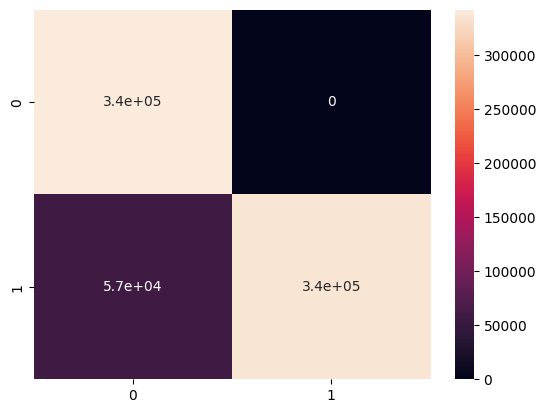

In [47]:
### Evaluation de la classification
from sklearn.metrics import confusion_matrix,classification_report
y_pred_train=classifier.predict(D_train)
best_pred_train=np.asarray([np.argmax(line)for line in y_pred_train])
cmt=confusion_matrix(y_train_balanced,best_pred_train)
sns.heatmap(cmt,annot=True)
y_pred_test=classifier.predict(D_test)

In [48]:
print(classification_report(y_train_balanced,best_pred_train))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92    341752
           1       1.00      0.86      0.92    393356

    accuracy                           0.92    735108
   macro avg       0.93      0.93      0.92    735108
weighted avg       0.93      0.92      0.92    735108



<Axes: >

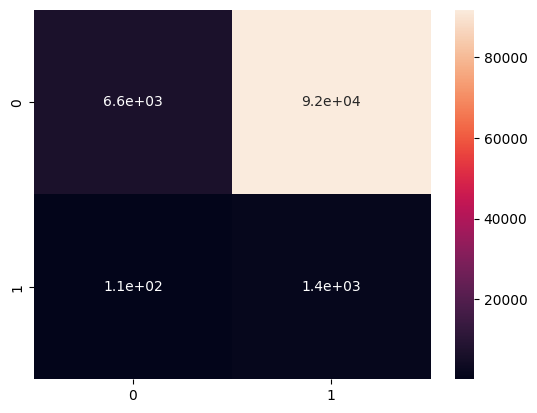

In [ ]:
#from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

#y_pred_test = classifier.predict(X_test_scaled)
#cmt = confusion_matrix(y_test, y_pred_test)
#sns.heatmap(cmt, annot=True)

In [49]:
# Inverser les prédictions
y_pred_corrected = 1 - y_pred_test

# Afficher les résultats corrigés
print(classification_report(y_test, y_pred_corrected))
print(confusion_matrix(y_test, y_pred_corrected))

ValueError: Classification metrics can't handle a mix of binary and continuous-multioutput targets